# Predicting whether a newspaper forecast came true

**Economy arm, BU RISE.** One notebook, end to end: the data, the features, the
model, the honest evaluation, and the caveats.

### The question

A newspaper printed an economic forecast — "business will improve," "prices will
fall." Given **what the forecast said** and **the economic data that was already
public when it went to press**, what is the probability it came true?

This is a *forecast-credibility* model. It never predicts the economy. It
predicts whether a particular forecast will land.

### The one rule that makes this a measurement

Whether a forecast came true is decided **by rule, from real data**
(`truth_data.py`: NBER business-cycle dates + FRED series, with documented
no-change bands). No language model decides correctness, and no economic
variable used as a *feature* below ever touches that decision. The scoring stage
is completely untouched by this notebook — everything here runs afterwards.

### Why this notebook imports instead of redefining

Every function used here comes from `macro_context.py` and `hit_predictor.py`,
which are covered by `tests/test_offline.py` (129 checks; 195 across all three suites). Copying the code into cells
would let the notebook silently drift from the tested pipeline, so it doesn't.

## 0 · Setup

Runs from anywhere in the repo (it locates the root itself). Requires `pandas`, `numpy`,
`scikit-learn`, `matplotlib`, `joblib`.

In [1]:
# Make src/ importable and run from the repo root -- the modules' data paths are
# repo-root-relative, same convention as tests/. Works from notebooks/ or root.
import sys, os, pathlib
_ROOT = pathlib.Path.cwd()
while not (_ROOT / "src").is_dir() and _ROOT != _ROOT.parent:
    _ROOT = _ROOT.parent
sys.path.insert(0, str(_ROOT / "src"))
os.chdir(_ROOT)

import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

import macro_context as mc
import hit_predictor as hp

# Okabe-Ito, colourblind-safe -- same palette as the poster figures.
BLUE, VERM, GRAY, INK, MUTED = "#0072B2", "#D55E00", "#9AA0A6", "#1a1a1a", "#6b6b6b"
plt.rcParams.update({
    "figure.dpi": 110, "font.size": 10, "axes.spines.top": False,
    "axes.spines.right": False, "axes.edgecolor": "#cccccc",
    "axes.grid": True, "grid.color": "#f0f0f0", "font.family": "DejaVu Sans"})

# The permutation test refits the model 200x and takes ~25 minutes.
# Published result: observed AUC 0.647, null mean 0.478, p = 0.005.
RUN_PERMUTATION_TEST = False

## 1 · The data

`monthly_scored.csv` — every month 1900-01 to 1963-12 of Library of Congress
newspaper pages, forecasts extracted by LLM, then **scored by rule**.

`macro_context.py` attaches the economy-at-print-time to each scored claim. If
`macro_context.csv` doesn't exist yet, build it first:

```
python src/macro_context.py
```

**Corpus caveat, carry it everywhere:** extraction used gpt-oss-120b
(gold-standard F1 ≈ 0.61), not the Gemini extractor used for the crisis corpus
(F1 ≈ 0.79). Aggregate patterns tolerate this; claim-for-claim comparison across
the two corpora does not.

In [ ]:
# WHICH CORPUS. ("loc",) is the published result and the default; the LOC and
# ProQuest tables are never merged on disk, only combined here at load time, so
# falling back is a one-token edit. See src/context_sources.py for why pooling
# is opt-in (disjoint eras, different labelling model, stock factors that stop
# in 1968). tests/test_context_sources.py asserts that ("loc",) reproduces the
# pre-ProQuest features exactly.
SOURCES = ("loc",)                      # ("loc", "proquest") to pool

from context_sources import load_context, stock_coverage_warning

d = load_context(SOURCES, verbose=True)
d = d[d["hit"].isin([0, 1])].reset_index(drop=True)

print(f"scored forecasts : {len(d):,}")
print(f"date range       : {d['date'].min()[:7]} to {d['date'].max()[:7]}")
print(f"hit rate         : {d['hit'].mean():.3f}   <- the base rate to beat")
if d["source"].nunique() > 1:
    print("\nby source (report these separately before pooling):")
    print(d.groupby("source")["hit"].agg(n="size", hit_rate="mean").round(3))
    stock_coverage_warning(d)
print("\nwhat was predicted:")
print(d.groupby("predicted_norm")["hit"].agg(n="size", hit_rate="mean").round(3)
        .sort_values("n", ascending=False))


### Read that table before going further

Forecasts of **improvement** came true 60% of the time; forecasts of a
**downturn** 36%; forecasts of **no change** 19%.

That is not skill. The economy expands most of the time, so a permanent optimist
is right more often than not, and the economy almost never stands still. Any
model below has to beat *this*, not 50%.

## 2 · Features — three blocks

**A · What the forecast said** (`claim_features`) — direction, topic, voice,
scope, hedged vs assertive, whether a named person is quoted, whether it
contains a number, its length, its horizon.

**B · What the economy was visibly doing** (`macro_block`) — 13 factors from
FRED: output growth/acceleration/gap, inflation level and acceleration,
unemployment level and change, stock returns (6m, 12m), volatility, drawdown
from peak, and policy uncertainty.

**C · The interaction** (`interaction_block`) — each factor multiplied by the
forecast's direction (+1 optimistic, −1 pessimistic, 0 for "no change").
Section 4 explains why this block is the whole model.

### Leakage discipline, non-negotiable

- Every series is shifted forward by its **own publication lag** before it is
  read. A forecast printed in month *M* sees only what was public by *M*.
- **Stock prices take no lag** — they were in the same day's paper.
- **NBER recession status is never a feature.** Recessions are dated 6–21 months
  after the fact, so it is an *outcome*. It exists in the CSV as
  `hindsight_in_recession` for figures only, and the cell below asserts it
  cannot reach the model.
- A missing factor (no unemployment before 1948) gets a `has_` flag rather than
  a zero — so "we don't know" is its own state, not a silent "it was flat."

In [3]:
y = d["hit"].astype(int).values
year = pd.to_datetime(d["date"]).dt.year
groups = ((year // mc.BLOCK_YEARS) * mc.BLOCK_YEARS).values   # 3-year periods

A = hp.claim_features(d)                    # what the forecast said
B = hp.macro_block(d[mc.FACTORS])           # what the economy was doing
C_ = hp.interaction_block(d, d[mc.FACTORS])  # direction x economy
X = pd.concat([A, B, C_], axis=1)

# Leakage assertion, not a comment.
assert not any("hindsight" in c for c in X.columns), "hindsight feature leaked!"

print(f"A  claim features       : {A.shape[1]:>3}")
print(f"B  economic state       : {B.shape[1]:>3}")
print(f"C  direction x economy  : {C_.shape[1]:>3}")
print(f"                  total : {X.shape[1]:>3} features, {len(X):,} rows")
print(f"\nheld-out periods        : {len(set(groups))} (3-year blocks)")

A  claim features       :  10
B  economic state       :  26
C  direction x economy  :   5
                  total :  41 features, 14,251 rows

held-out periods        : 22 (3-year blocks)


## 3 · How it is validated — and why not a random split

**`LeaveOneGroupOut`, where a group is a 3-year period.** Train on every other
period, predict the held-out one, repeat, then pool all held-out predictions and
score once.

A random split would be **wrong here**, not merely suboptimal. Forecasts printed
in the same years share one economy and largely one set of outcomes — so a
random split puts near-duplicate answers on both sides of the fence and the
model scores well by memorising the era. Splitting by time period forces it to
generalise to conditions it has never seen.

Predictions are **pooled** across folds rather than averaged per fold, because
the folds differ wildly in size and an average of per-fold AUCs would
over-weight thin periods.

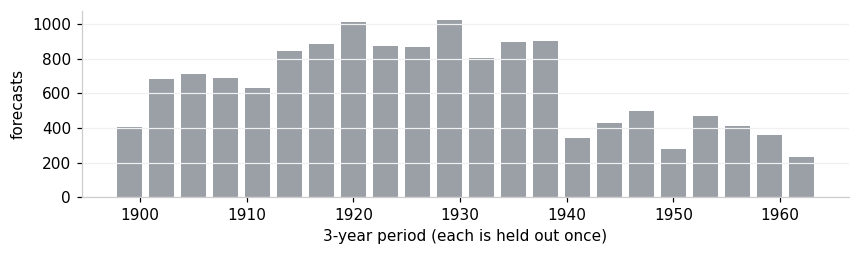

22 folds | smallest 231 forecasts | largest 1025


In [4]:
sizes = pd.Series(groups).value_counts().sort_index()
fig, ax = plt.subplots(figsize=(9, 2.2))
ax.bar(sizes.index, sizes.values, width=2.4, color=GRAY)
ax.set_ylabel("forecasts"); ax.set_xlabel("3-year period (each is held out once)")
ax.grid(axis="x", visible=False)
plt.show()
print(f"{len(sizes)} folds | smallest {sizes.min()} forecasts | largest {sizes.max()}")

## 4 · The nested ladder

Each rung adds one thing, so the contribution of each block is *visible* rather
than asserted.

| rung | what it tests |
|---|---|
| base rate | the null — no model at all |
| claim only | does *how a forecast is written* predict its accuracy? |
| economy only | does *the state of the economy* predict it? |
| both, additive | do they add up? |
| **+ direction × economy** | **does the economy's effect depend on which way the forecast pointed?** |
| gradient boosting | is the linear model leaving nonlinear structure behind? |

**Metrics** (`accuracy` is deliberately absent — it is a project-wide rule; an
always-say-yes model scores ~51% here and looks respectable):

- **ROC-AUC** — show the model one forecast that came true and one that didn't;
  how often does it rank them correctly? 0.5 = coin flip.
- **PR-AUC** — better behaved when the classes are lopsided.
- **Brier** — mean squared error of the predicted probabilities. *This is the
  closest thing to RMSE here.* Lower is better. (There is no RMSE proper: the
  target is yes/no, so this is classification, not regression.)

In [5]:
from sklearn.metrics import average_precision_score, brier_score_loss

rows = []
oof_store = {}
for name, cat, num in hp.LADDER:
    if not cat and not num:                       # the null
        const = np.full(len(y), y.mean())
        rows.append({"model": name, "ROC-AUC": np.nan,
                     "PR-AUC": average_precision_score(y, const),
                     "Brier": brier_score_loss(y, const)})
        continue
    oof = hp.oof_predict(X, y, groups, cat, num)
    m = hp.metrics(y, oof)
    oof_store[name] = (oof, cat, num)
    rows.append({"model": name, "ROC-AUC": m["auc"],
                 "PR-AUC": m["pr_auc"], "Brier": m["brier"]})

ladder = pd.DataFrame(rows).set_index("model")
print(ladder.round(3).to_string())

                               ROC-AUC  PR-AUC  Brier
model                                                
1. base rate (no model)            NaN   0.513  0.250
2. claim features only           0.561   0.514  0.245
3. economy only                  0.538   0.551  0.260
4. claim + economy (additive)    0.581   0.594  0.255
5. + direction x economy         0.647   0.652  0.241


In [6]:
# Same inputs, non-linear learner -- an honesty check on the linear model.
from sklearn.ensemble import HistGradientBoostingClassifier

full_name = "5. + direction x economy"
_, cat_f, num_f = oof_store[full_name]
oof_gb = hp.oof_predict(X, y, groups, cat_f, num_f,
                        clf=HistGradientBoostingClassifier(
                            max_depth=3, max_iter=200, learning_rate=.06,
                            random_state=hp.SEED))
m_gb = hp.metrics(y, oof_gb)
print(f"gradient boosting (same inputs): ROC-AUC {m_gb['auc']:.3f}")
print("-> does NOT beat the linear model, so logistic regression stays primary")
print("   and its coefficients are an honest summary, not a simplification.")

gradient boosting (same inputs): ROC-AUC 0.617
-> does NOT beat the linear model, so logistic regression stays primary
   and its coefficients are an honest summary, not a simplification.


### What the ladder says

- **Neither block alone gets far.** How a forecast is written: 0.561. The
  economy at print time: 0.538.
- **Adding them barely helps** (0.581) — which looks like the economy carrying
  almost no information.
- **Letting them interact jumps to 0.647.** That +0.066 is the finding.

These are point estimates. §6 puts an interval on each, and it does not treat
them equally: the interaction rung survives, the rungs beneath it mostly do not.
Read this table again after §6 before quoting any single number from it.

## 5 · Why the interaction is the whole model

An additive model has *one* coefficient per economic factor, and it has to serve
optimists and pessimists at once. But a rising market makes an upbeat forecast
**more** likely to come true and a downbeat one **less** likely. One number
cannot say both, so it settles near zero.

This is why `model_hit.py` reported a macro-only AUC of 0.505 and read it as a
genuine null. That reading is true of the *pooled* sample and false within it.
The plot below is the correction — the same economic conditions, split by what
the forecast predicted.

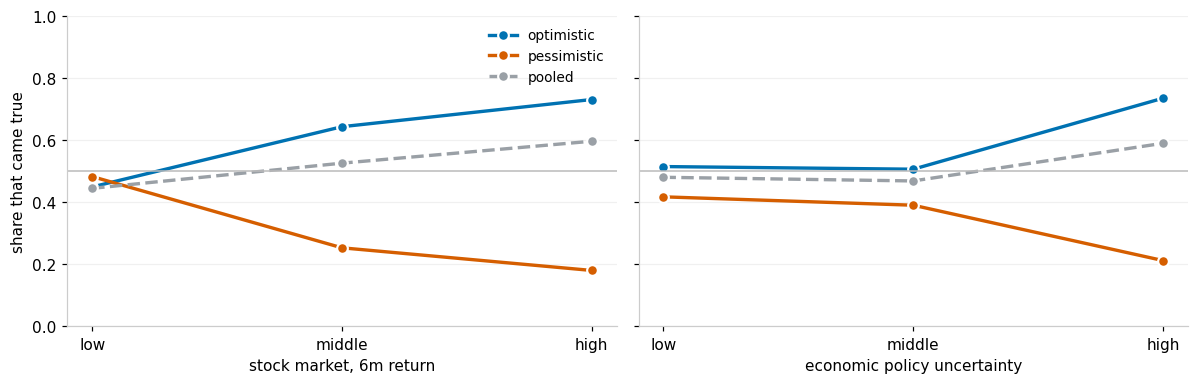

In [7]:
def tercile_plot(ax, factor):
    v = d[factor]
    edges = np.unique(np.nanpercentile(v[v.notna()], [0, 100/3, 200/3, 100]))
    b = pd.cut(v, bins=edges, labels=["low", "mid", "high"], include_lowest=True)
    opt = d["predicted_norm"].isin(["improve", "up"])
    pes = d["predicted_norm"].isin(["worsen", "down"])
    for mask, color, lbl in [(opt, BLUE, "optimistic"), (pes, VERM, "pessimistic"),
                             (pd.Series(True, index=d.index), GRAY, "pooled")]:
        rate = [d.loc[mask & (b == t), "hit"].mean() for t in ["low", "mid", "high"]]
        ax.plot([0, 1, 2], rate, color=color, lw=2.2, marker="o", ms=7,
                ls="--" if lbl == "pooled" else "-", label=lbl, mec="white", mew=1.4)
    ax.axhline(.5, color="#bbbbbb", lw=1)
    ax.set_xticks([0, 1, 2]); ax.set_xticklabels(["low", "middle", "high"])
    ax.set_ylim(0, 1); ax.set_xlabel(mc.PRETTY[factor]); ax.grid(axis="x", visible=False)

fig, axes = plt.subplots(1, 2, figsize=(11, 3.6), sharey=True)
for ax, f in zip(axes, ["stock_ret6", "epu"]):
    tercile_plot(ax, f)
axes[0].set_ylabel("share that came true"); axes[0].legend(frameon=False, fontsize=9)
plt.tight_layout(); plt.show()

**The scissors.** As conditions improve, optimistic forecasts get *more* likely
to come true and pessimistic ones *less*. The two lines cross. Pooled (grey),
they largely cancel — which is exactly what a model without an interaction term
sees.

What genuinely does nothing, in every stratum: **industrial output growth and
inflation.** That part of the original null stands. It is the *market and
policy-uncertainty* conditions that carry the signal.

## 6 · How wide are these numbers?

Every AUC above is a point estimate, and §9's permutation test only asks whether
the model beats **no signal at all**. It never asks the question the ladder
actually poses — *is rung 5 better than rung 4?* — nor how much the headline
number would move on a different draw of history. Two block bootstraps, below,
answer exactly those.

**Resample whole 3-year periods, never individual claims.** This is the same
discipline as the CV split and for the same reason: claims inside one period
share one economy and one set of outcomes, so an i.i.d. bootstrap over 14,251
rows would report an interval roughly √(claims-per-block) — about 25× — too
narrow, and turn noise into findings. The effective sample is **22 blocks**, and
the intervals should look like it.

**The lift bootstrap is *paired*.** Rungs 4 and 5 share nearly every input and
most of their errors, so both are scored on the *same* resampled blocks and the
difference is taken within each draw. Comparing two independently drawn
intervals would throw away that correlation and understate what we know about
the gap — which matters here, because the two marginal intervals overlap
heavily.

  rung                                AUC            95% CI
  2. claim features only            0.561   [0.461, 0.666]   <- includes chance
  3. economy only                   0.538   [0.501, 0.573]
  4. claim + economy (additive)     0.581   [0.504, 0.652]
  5. + direction x economy          0.647   [0.571, 0.713]


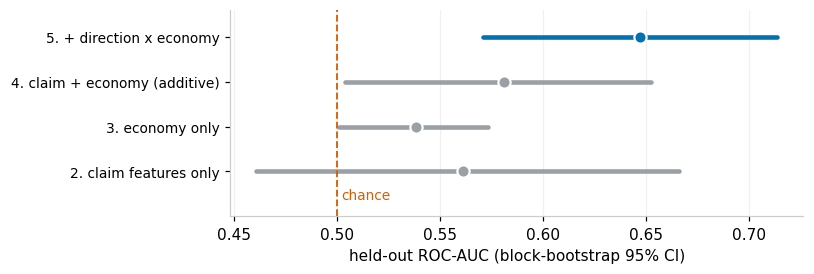

In [8]:
# 2,000 resamples of the 22 periods, per rung. ~15s.
ci = {}
for name, (o, _, _) in oof_store.items():
    ci[name] = hp.block_boot_auc(y, o, groups, reps=2000)

print(f"  {'rung':<32}{'AUC':>7}{'95% CI':>18}")
for name, (a, lo, hi) in ci.items():
    flag = "" if lo > 0.5 else "   <- includes chance"
    print(f"  {name:<32}{a:>7.3f}   [{lo:.3f}, {hi:.3f}]{flag}")

fig, ax = plt.subplots(figsize=(7.5, 2.6))
for i, (name, (a, lo, hi)) in enumerate(ci.items()):
    c = BLUE if name == full_name else GRAY
    ax.plot([lo, hi], [i, i], color=c, lw=3, solid_capstyle="round")
    ax.plot([a], [i], "o", color=c, ms=8, mec="white", mew=1.4)
ax.axvline(.5, color=VERM, lw=1.2, ls="--")
ax.text(.502, -.62, "chance", color=VERM, fontsize=9)
ax.set_yticks(range(len(ci))); ax.set_yticklabels(list(ci), fontsize=9)
ax.set_xlabel("held-out ROC-AUC (block-bootstrap 95% CI)")
ax.grid(axis="y", visible=False); ax.set_ylim(-1, len(ci) - .4)
plt.tight_layout(); plt.show()

### The intervals change how three of the rungs must be reported

| rung | AUC | 95% CI | reading |
|---|---|---|---|
| claim features only | 0.561 | [0.461, 0.666] | **spans chance** — how a forecast is written is *not* established as predictive |
| economy only | 0.538 | [0.501, 0.573] | barely clears chance |
| claim + economy (additive) | 0.581 | [0.504, 0.652] | barely clears chance |
| **+ direction × economy** | **0.647** | **[0.571, 0.713]** | clearly above chance |

The headline holds with room to spare. But "neither block alone gets far" was an
understatement: **claim-only cannot be distinguished from a coin flip at all**
once the block structure is respected. Its 0.561 came from 22 effective
observations, not 14,251, and it should not be cited on its own.

In [9]:
# Is the interaction rung better than the rung below it? Paired on blocks.
add_name = "4. claim + economy (additive)"
for base in [add_name, "2. claim features only"]:
    dl, lo, hi, p = hp.block_boot_auc_delta(
        y, oof_store[base][0], oof_store[full_name][0], groups, reps=2000)
    verdict = "excludes 0" if lo > 0 or hi < 0 else "SPANS 0 -- not distinguishable"
    print(f"  full - ({base})")
    print(f"    {dl:+.3f}   95% CI [{lo:+.3f}, {hi:+.3f}]   p = {p:.4f}   {verdict}\n")

  full - (4. claim + economy (additive))
    +0.066   95% CI [+0.028, +0.096]   p = 0.0020   excludes 0



  full - (2. claim features only)
    +0.086   95% CI [+0.028, +0.140]   p = 0.0030   excludes 0



### The lift survives, and pairing is why we can see it

**+0.066 over the additive model, 95% CI [+0.028, +0.096], p = 0.002.**
Over claim-only: **+0.086, CI [+0.028, +0.140], p = 0.003.**

Look at what pairing bought. The marginal intervals for rungs 4 and 5 —
[0.504, 0.652] and [0.571, 0.713] — overlap across most of their length, and
eyeballing two overlapping intervals is the standard way to talk yourself out of
a real effect. The paired difference excludes zero comfortably, because the two
models rise and fall *together* across resampled histories: whichever periods
you draw, the interaction rung beats the additive one on them. That is a much
stronger statement than either interval alone, and it is the correct test for
nested models scored on identical rows.

So §5's claim survives the interval treatment. **§4's does not, for the rungs
below it** — report the interaction lift, not the individual sub-model AUCs.

## 7 · Calibration — do the probabilities mean anything?

AUC only measures *ranking*. A model can rank perfectly and still be badly
wrong about the numbers. Calibration asks: of the forecasts this model called
"80% likely," did about 80% actually come true?

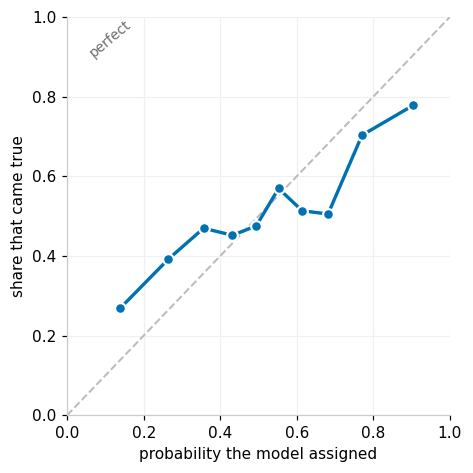

Brier score: 0.241


In [10]:
from sklearn.calibration import calibration_curve

oof_full = oof_store[full_name][0]
ok = ~np.isnan(oof_full)
frac, mean_pred = calibration_curve(y[ok], oof_full[ok], n_bins=10, strategy="quantile")

fig, ax = plt.subplots(figsize=(4.4, 4.4))
ax.plot([0, 1], [0, 1], color="#bbbbbb", lw=1.3, ls="--")
ax.plot(mean_pred, frac, color=BLUE, lw=2.2, marker="o", ms=7, mec="white", mew=1.4)
ax.set_xlim(0, 1); ax.set_ylim(0, 1)
ax.set_xlabel("probability the model assigned"); ax.set_ylabel("share that came true")
ax.text(.05, .9, "perfect", color=MUTED, fontsize=9, rotation=40)
plt.tight_layout(); plt.show()
print(f"Brier score: {brier_score_loss(y[ok], oof_full[ok]):.3f}")

**Monotone but too extreme at both ends** — it says 0.90 where the truth is
0.78, and 0.14 where the truth is 0.27. Ridge logistic on 41 correlated features
is over-confident at the tails, which is ordinary and *fixable*: it is a
distortion of the probability scale, not of the ranking.

### Fixing it, without cheating

Fit a monotone map from predicted probability to observed frequency — but fit it
**inside the training fold**, on periods the classifier underneath it did not
see, and leave the held-out period untouched by both. A calibrator fitted on
rows the classifier already trained on learns the *training* fit's
over-confidence rather than the deployed model's, and draws a curve that looks
far better than the model is. `hp.oof_predict(..., calibrate=...)` does the
nested, period-grouped version.

Because both maps are monotone, ranking is unchanged by construction — the only
thing that can move is the Brier score, i.e. whether the output may be quoted as
odds or only as a rank.

                   Brier     AUC
  uncalibrated    0.2411  0.6469
  isotonic        0.2342  0.6439
  sigmoid         0.2386  0.6217


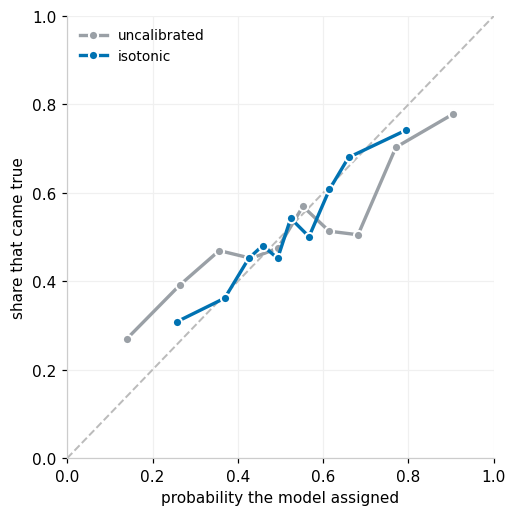

In [11]:
# Nested calibration: 22 outer folds x 5 inner period-grouped splits, twice. ~40s.
cal = {"uncalibrated": oof_full}
for method in ["isotonic", "sigmoid"]:
    cal[method] = hp.oof_predict(X, y, groups, cat_f, num_f, calibrate=method)

print(f"  {'':<14}{'Brier':>8}{'AUC':>8}")
for name, o in cal.items():
    m = hp.metrics(y, o)
    print(f"  {name:<14}{m['brier']:>8.4f}{m['auc']:>8.4f}")

fig, ax = plt.subplots(figsize=(4.8, 4.8))
ax.plot([0, 1], [0, 1], color="#bbbbbb", lw=1.3, ls="--")
for name, color in [("uncalibrated", GRAY), ("isotonic", BLUE)]:
    o = cal[name]
    k = ~np.isnan(o)
    f_, p_ = calibration_curve(y[k], o[k], n_bins=10, strategy="quantile")
    ax.plot(p_, f_, color=color, lw=2.2, marker="o", ms=6, mec="white", mew=1.3,
            label=name)
ax.set_xlim(0, 1); ax.set_ylim(0, 1); ax.legend(frameon=False, fontsize=9)
ax.set_xlabel("probability the model assigned"); ax.set_ylabel("share that came true")
plt.tight_layout(); plt.show()

### Isotonic wins; the tails are fixed, the middle is just noisy

| | Brier | AUC |
|---|---|---|
| uncalibrated | 0.2411 | 0.6469 |
| **isotonic** | **0.2342** | 0.6439 |
| sigmoid (Platt) | 0.2386 | 0.6217 |

The over-confidence is gone where it mattered: the top decile drops from *saying*
0.90 against a true 0.78 to saying 0.795 against a true 0.742, and the bottom
from 0.14 / 0.27 to 0.256 / 0.308. Platt loses because a single logistic squash
cannot fix both tails at once, and it visibly costs ranking (0.622).

Two honest caveats on the isotonic result:

- **AUC slips 0.647 → 0.644.** Isotonic is a *step* function, so ties appear
  where distinct probabilities are mapped to one value, and tied pairs score
  half. It is a rounding artefact of the calibrator, not lost signal.
- **The middle deciles stay wobbly** (0.493 → 0.452, 0.567 → 0.501). The
  empirical curve is not monotone there — with ~1,400 claims a decile spread
  over 22 correlated periods, that is sampling noise, and no calibrator removes
  it.

**Revised guidance, replacing "ranking only":** use the *isotonic* output as a
probability. Near the tails it can be quoted as odds. In the 0.45–0.60 band the
differences are inside the noise, so rank there and do not read a 0.49 against a
0.57 as a real gap.

## 8 · What carries the signal

Permutation importance: shuffle one input **inside the held-out fold** and see
how far the out-of-fold AUC drops. Doing this on held-out data measures what
actually *generalises* — a training-set importance would only report what the
model chose to lean on.

*(One repeat per feature here for speed; the committed run used three.)*

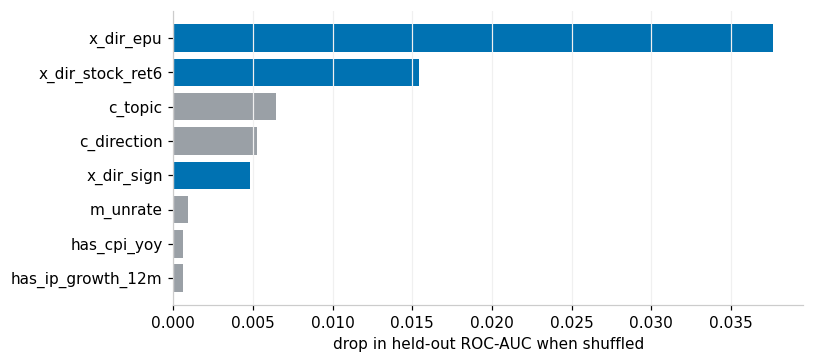

blue = interaction terms

         feature   drop  sd
       x_dir_epu 0.0376 0.0
x_dir_stock_ret6 0.0154 0.0
         c_topic 0.0064 0.0
     c_direction 0.0052 0.0
      x_dir_sign 0.0048 0.0
        m_unrate 0.0009 0.0


In [12]:
imp = hp.permutation_importance_grouped(
    X, y, groups, cat_f, num_f, base_auc=ladder.loc[full_name, "ROC-AUC"], reps=1)

top = imp.head(8).iloc[::-1]
fig, ax = plt.subplots(figsize=(7.5, 3.4))
ax.barh(top["feature"], top["drop"],
        color=[BLUE if f.startswith("x_dir_") else GRAY for f in top["feature"]])
ax.set_xlabel("drop in held-out ROC-AUC when shuffled")
ax.grid(axis="y", visible=False)
plt.tight_layout(); plt.show()
print("blue = interaction terms\n")
print(imp.head(6).round(4).to_string(index=False))

**The gain is two terms**: direction × policy uncertainty, and direction ×
stock return. Every economic **main effect** is ≈ 0 or negative.

This is the same conclusion as the scissors plot, reached independently by a
different method — the economy predicts accuracy *only* in interaction with the
forecast's direction, never on its own.

## 9 · The caveat that must ship with the number

Policy uncertainty (EPU) is the single largest contributor. It is also the
weakest link, for three reasons:

1. **Shared instrument.** The historical EPU index is built by counting
   uncertainty language **in newspapers** — the same medium this corpus is drawn
   from. Circularity is plausible and is *not* ruled out here.
2. **It did not replicate** on the independent crisis corpus (+0.084 / −0.012,
   essentially nothing), while the market factors did replicate in sign.
3. Its coverage rests on one third-party spreadsheet the rest of the pipeline
   does not depend on.

So: refit with EPU removed entirely and see what survives.

In [13]:
drop = {c for c in X.columns if "epu" in c}
abl = []
for name, cat, num in hp.LADDER:
    num2 = [c for c in num if c not in drop]
    if not cat and not num2:
        continue
    m = hp.metrics(y, hp.oof_predict(X, y, groups, cat, num2))
    abl.append({"model": name, "without EPU": m["auc"],
                "with EPU": ladder.loc[name, "ROC-AUC"]})
pd.set_option("display.width", 120)
print(pd.DataFrame(abl).set_index("model").round(3).to_string())

                               without EPU  with EPU
model                                               
2. claim features only               0.561     0.561
3. economy only                      0.502     0.538
4. claim + economy (additive)        0.554     0.581
5. + direction x economy             0.587     0.647


**The interaction structure survives without EPU** — 0.587 still beats
claim-only (0.561) and the additive model (0.554), and the interaction still
adds ~+0.03. But EPU accounts for roughly 0.060 of the 0.086 total lift.

**Report 0.587 / 0.647 together. Never 0.647 alone.**

## 10 · Is the whole thing better than chance?

**Block permutation test.** Shuffle the answers *within* each 3-year period,
refit, repeat 200 times, and see how often chance produces a score this good.

Shuffling *within* period is the point: it destroys the forecast-level signal
while preserving the era structure, so the test cannot be passed by a model that
merely learned which decades were good ones.

This is the complement of §6, not a repeat of it: the bootstrap asks *how wide*
the number is, this asks *how often chance clears it*. Both are needed, and they
agree — the CI's lower bound is 0.571 and the null distribution centres on 0.478.

**Published result: observed AUC 0.647, null mean 0.478, p = 0.005.**
Set `RUN_PERMUTATION_TEST = True` at the top to reproduce (~25 minutes).

In [14]:
if RUN_PERMUTATION_TEST:
    rng = np.random.default_rng(hp.SEED)
    null = []
    for i in range(200):
        yp = y.copy()
        for g in set(groups):
            idx = np.where(groups == g)[0]
            yp[idx] = rng.permutation(yp[idx])
        m = hp.metrics(yp, hp.oof_predict(X, yp, groups, cat_f, num_f))
        if m:
            null.append(m["auc"])
    obs = ladder.loc[full_name, "ROC-AUC"]
    p = (1 + sum(a >= obs for a in null)) / (1 + len(null))
    print(f"observed {obs:.3f} | null mean {np.mean(null):.3f} | p = {p:.4f}")
else:
    print("skipped -- published result: observed 0.647, null mean 0.478, p = 0.005")

skipped -- published result: observed 0.647, null mean 0.478, p = 0.005


## 11 · Using it on a new forecast

The evaluation above is the honest estimate of how well this generalises. The
*deployed* model is then fit on every available historical example.

Note what `predict_new` returns: the **uncalibrated** probability, because the
saved pipeline is the plain one. Apply §7's reading to these numbers — the
extremes below are the direction isotonic pulls in.

In [15]:
demo = hp.predict_new(hp.DEMO)
for f, p in zip(hp.DEMO, demo):
    print(f"P(comes true) = {p:.3f}   {f['date']}  [{f['direction']}/{f['topic']}]")
    print(f"                          \"{f['quote']}\"\n")

P(comes true) = 0.608   1929-06-15  [improve/markets]
                          "Stock prices will continue their advance through the coming year."

P(comes true) = 0.234   1929-06-15  [worsen/markets]
                          "The market is dangerously overextended and must break."

P(comes true) = 0.484   1933-03-01  [improve/general_business]
                          "Business will recover substantially within the year."



`predict_new` **refuses to score** if a load-bearing economic factor could not
be loaded, rather than returning a confident wrong number. That guard exists
because of this notebook: on its first run EPU silently failed to load, and the
1929 bull scored **0.269 instead of 0.608** — the answer inverted. `macro_block`
fills a missing factor with 0.0, which is right during training (the `has_` flag
lets the model treat pre-1919 as its own regime) and catastrophic at predict
time against a model trained *with* that factor.

**This demo is deliberately unflattering.** In June 1929 the model rates the
bull 0.61 and the bear 0.23 — and the bear was right within four months.

It is reading the pre-crash market's momentum, which is exactly what it was
trained to do and exactly why it **cannot call turning points**: the conditions
that make an upbeat forecast usually right are the same conditions that precede
a crash. Anyone demoing this should show these three, not cherry-picked wins.

## 12 · Methods summary

| Purpose | Method |
|---|---|
| Primary model | **Logistic regression**, L2 (ridge), `C=0.5` |
| Nonlinearity check | **Gradient boosting** (`HistGradientBoostingClassifier`, depth 3) — lost, so linear stayed primary |
| Categorical encoding | One-hot, categories with < 15 examples pooled |
| Numeric encoding | Standardisation (z-scores) |
| Assembly | `ColumnTransformer` + `Pipeline`, fit **inside** each fold so preprocessing cannot leak |
| Validation | `LeaveOneGroupOut` over 3-year periods; predictions pooled, never averaged per fold |
| Ranking metric | **ROC-AUC** (primary), **PR-AUC** |
| Probability metric | **Brier score** (= MSE of predicted probabilities; the RMSE analogue) + **calibration curve**, 10 quantile bins |
| Probability correction | **Isotonic regression**, fitted in a nested period-grouped inner CV (`hp.oof_predict(..., calibrate=)`); beat Platt |
| Deliberately excluded | **Accuracy** — an always-say-yes model scores ~51% here |
| Significance | **Block permutation test**, 200 within-period shuffles |
| Interval on the AUC | **Block bootstrap** over 3-year periods, 2,000 resamples (`hp.block_boot_auc`) |
| Interval on a model *comparison* | **Paired** block bootstrap on the AUC difference between nested rungs (`hp.block_boot_auc_delta`) |
| Interval on proportions | **Wilson** score intervals |
| Multiple comparisons | **Benjamini–Hochberg** FDR across the 13-factor family |
| Attribution | **Permutation importance** on held-out folds |
| Robustness | **Ablation** (`--exclude epu`); replication on the independent crisis corpus |
| Reproducibility | Fixed `SEED = 0` throughout |

### Bottom line

**0.647 (95% CI [0.571, 0.713]) with EPU, 0.587 without.** Real, modest, and
significant on two independent tests — a block bootstrap whose interval clears
chance, and a permutation test at p = 0.005. Meaningfully better than chance,
nowhere near an oracle for any individual forecast.

The finding is the **interaction**, and it is the part that survives every check:
**+0.066 over the additive model, CI [+0.028, +0.096], p = 0.002.** The rungs
beneath it do not survive — claim-only's interval spans chance outright.

The honest one-liner: *a forecast's odds are partly readable in advance, but
only from the forecast and the economy **together** — neither alone gets far,
and the readable part is mostly "which way did it point, and where were we in
the cycle."*

That matches what `forecast_credibility.py` found for professional forecasters
(Greenbook / SPF / Livingston): **credibility is mostly turning-point proximity,
not a property of the forecast itself.**

### Known limits

- Extraction quality (F1 ≈ 0.61) puts real label noise under every number here.
- ~8–12 US recessions in the whole period: inherently underpowered on
  turning points.
- 22 blocks is the effective sample for every interval above. The intervals are
  wide because the evidence is, and no amount of claim-level data narrows them.
- Economic-state features use **final revised** FRED values shifted by a
  publication lag, not true real-time vintages (RTDSM would be the upgrade).
- `voice` was never hand-graded — no kappa exists for it.
- The saved model is uncalibrated; isotonic is evaluated but not yet the
  deployed artefact.